In [1]:
# notebook for plotting the promoters containing HNF Family TF binding sites called by the seqlets for comparing the seqlets called by each method

In [1]:
# import packages
import pandas as pd
import matplotlib.pyplot as mpl
import seaborn as sns
from collections import Counter
from tqdm import tqdm
import torch
import re
import numpy as np
from scipy import stats
import pickle
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme

In [2]:
# open all MPAC seqlet calls
# k562
mpac_k_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_k562_seqlet_calls.tsv', sep = '\t')
mpac_k_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_k562_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_k562_plotLogo_dict.pkl', 'rb') as f:
    mpac_k_plotLogo_dict = pickle.load(f)
# hepg2
mpac_h_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_hepg2_seqlet_calls.tsv', sep = '\t')
mpac_h_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_hepg2_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_hepg2_plotLogo_dict.pkl', 'rb') as f:
    mpac_h_plotLogo_dict = pickle.load(f)
# sknsh
mpac_s_seqlet_calls = pd.read_csv('../mpac/processed_data/mpac_sknsh_seqlet_calls.tsv', sep = '\t')
mpac_s_full_ann_seqlets = pd.read_csv('../mpac/processed_data/mpac_sknsh_full_ann_seqlets.tsv', sep = '\t')
with open('../mpac/processed_data/mpac_sknsh_plotLogo_dict.pkl', 'rb') as f:
    mpac_s_plotLogo_dict = pickle.load(f)

In [3]:
# open PARM seqlet calls
# k562
parm_k_seqlet_calls = pd.read_csv('../PARM/processed_data/parm_k562_tangermeme_seqlet_calls.tsv', sep = '\t')
parm_k_full_ann_seqlets = pd.read_csv('../PARM/processed_data/parm_k562_tangermeme_full_ann_seqlets.tsv', sep = '\t')
with open('../PARM/processed_data/parm_k562_tangermeme_plotLogo_dict.pkl', 'rb') as f:
    parm_k_plotLogo_dict = pickle.load(f)
# hepg2
parm_h_seqlet_calls = pd.read_csv('../PARM/processed_data/parm_hepg2_tangermeme_seqlet_calls.tsv', sep = '\t')
parm_h_full_ann_seqlets = pd.read_csv('../PARM/processed_data/parm_hepg2_tangermeme_full_ann_seqlets.tsv', sep = '\t')
with open('../PARM/processed_data/parm_hepg2_tangermeme_plotLogo_dict.pkl', 'rb') as f:
    parm_h_plotLogo_dict = pickle.load(f)

In [4]:
# open promoterAI seqlet calls
promoterAI_seqlet_calls = pd.read_csv('../promoterAI/processed_data/promoterAI_seqlet_calls.tsv', sep = '\t')
promoterAI_full_ann_seqlets = pd.read_csv('../promoterAI/processed_data/promoterAI_full_ann_seqlets.tsv', sep = '\t')
with open('../promoterAI/processed_data/promoterAI_plotLogo_dict.pkl', 'rb') as f:
    promoterAI_plotLogo_dict = pickle.load(f)

In [5]:
def plot_specific_logos_mpac (seqlets,
                         annotated_seqlets,
                         promoter_id,
                         plotLogo_tensors,
                         cell,
                         model):
    # define highlight color
    if cell == 'K562':
        highlight = '#00A79D'
    elif cell == 'HepG2':
        highlight = '#FBB040'
    elif cell == 'SKNSH':
        highlight = '#ED1C24'
    # make a dictionary for annotating seqlets calls with promoters
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    if len(pro_seqlets) > 0:
        mpl.figure(figsize=(20,1), dpi=300)
        ax = mpl.subplot(111)
        plot_logo(plotLogo_tensors[promoter_id], annotations=pro_ann, score_key='attribution')
        for idx, row in pro_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.15, color=highlight)
        #mpl.ylim(-.5, .5)
        mpl.title(f'{model} {cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[promoter_id])
        mpl.title(f'{model} {cell} | tangermeme seqlets for {promoter_id}')
        mpl.show()

In [6]:
def plot_specific_logos_pAI (seqlets,
                         annotated_seqlets,
                         promoter_id,
                         plotLogo_tensors):
    
    promoter_idx = list(plotLogo_tensors.keys()).index(promoter_id)
    # filter for the random enhancer by enhancer index
    pro_seqlets = seqlets[seqlets['example_idx'] == promoter_idx]
    pro_ann = annotated_seqlets.iloc[pro_seqlets.index]
    if len(pro_seqlets) > 0:
        mpl.figure(figsize=(20,1), dpi=300)
        ax = mpl.subplot(111)
        plot_logo(plotLogo_tensors[promoter_id], annotations=pro_ann, score_key='attribution')
        for idx, row in pro_seqlets.iterrows():
            start, stop = row[['start', 'end']].tolist()
            ax.axvspan(start - 0.5, stop + 0.5, alpha=0.15, color='palevioletred')
        #mpl.ylim(-.5, .5)
        mpl.title(f'promoterAI tangermeme seqlets for {promoter_id}')
        mpl.show()
    else:
        print('no seqlets for this enhancer at this threshold')
        mpl.figure(figsize=(20,1), dpi=300)
        plot_logo(plotLogo_tensors[promoter_id])
        mpl.title(f'promoterAI tangermeme seqlets for {promoter_id}')
        mpl.show()

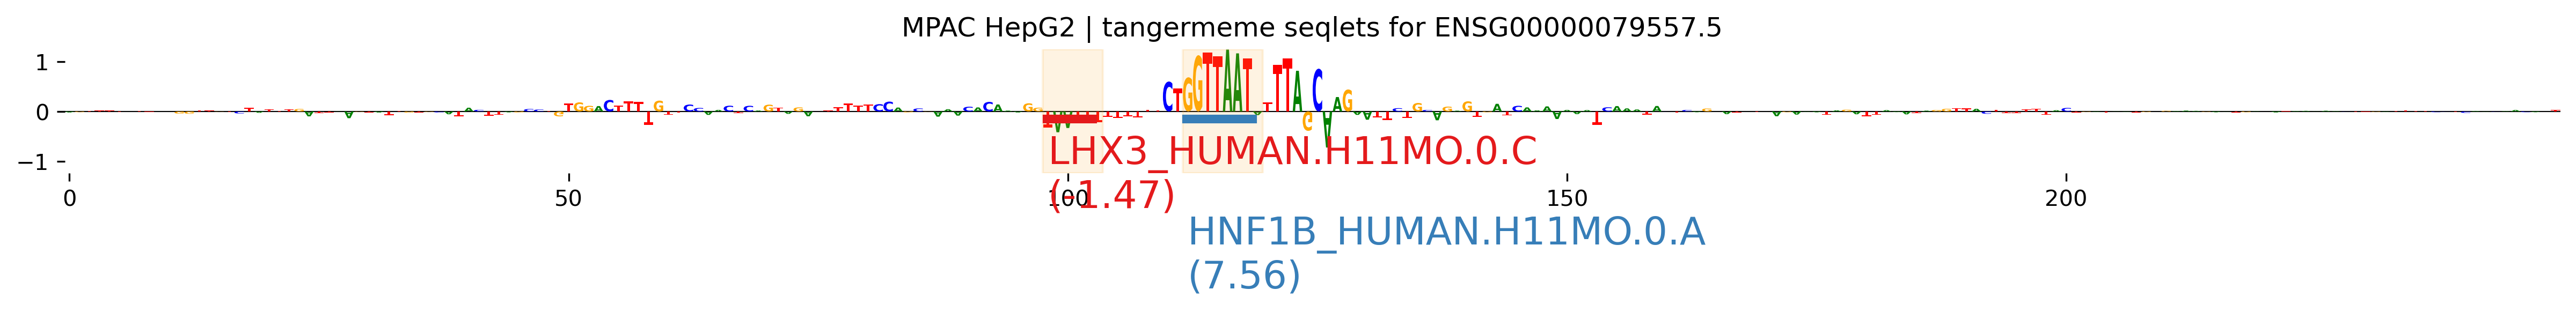

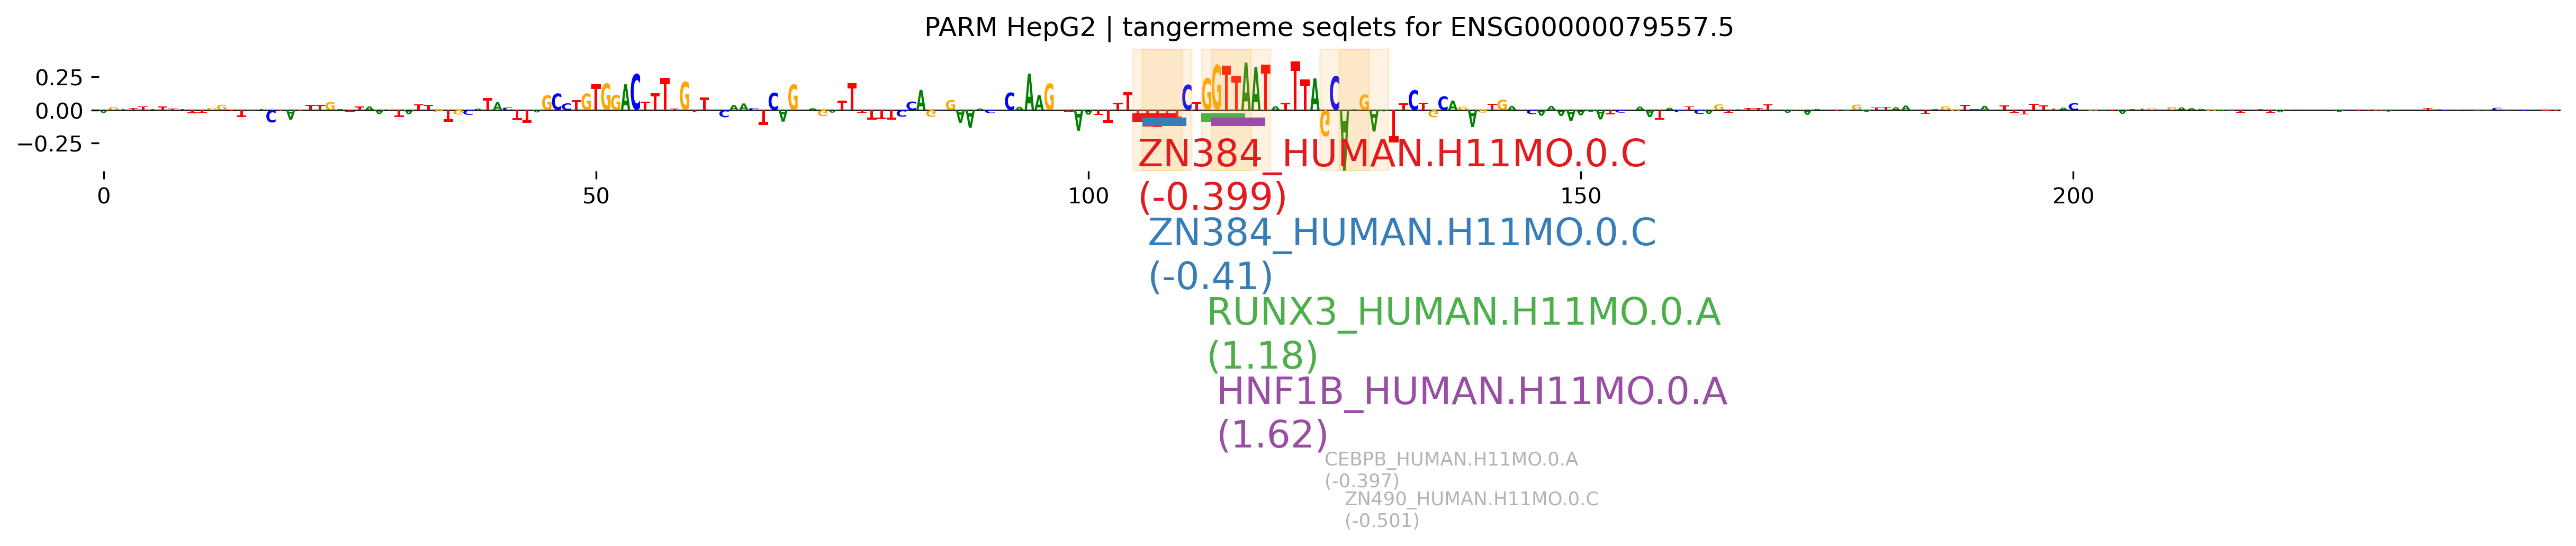

no seqlets for this enhancer at this threshold


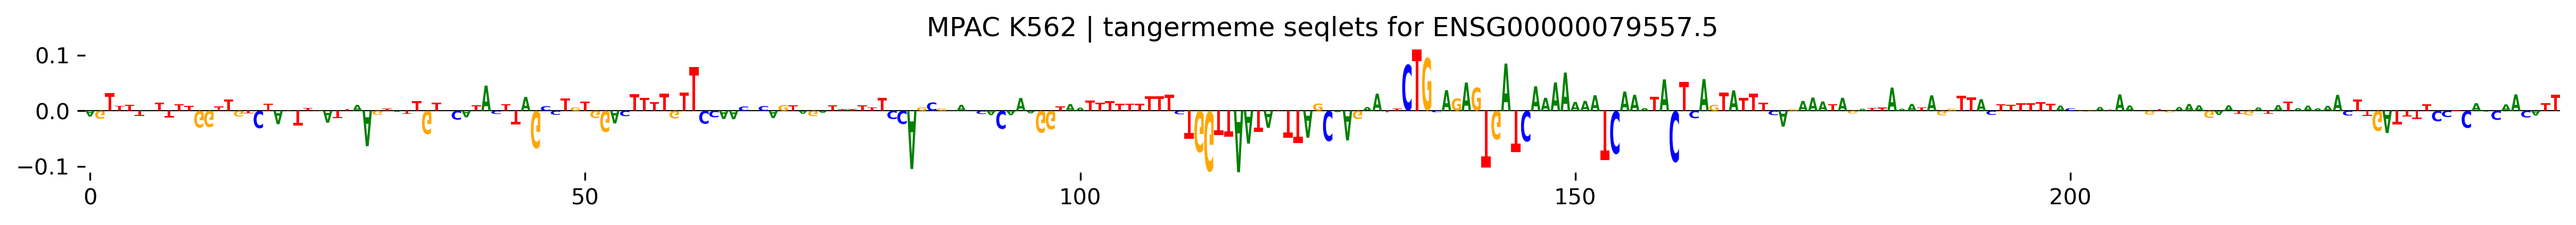

no seqlets for this enhancer at this threshold


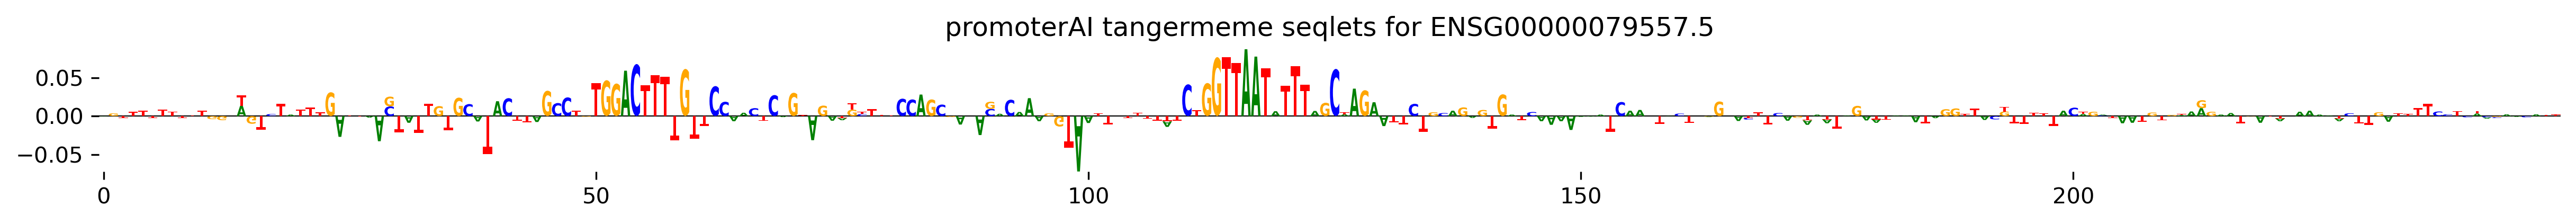

In [8]:
# ENSG00000079557.5
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000079557.5',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000079557.5',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# mpac k562
plot_specific_logos_mpac(
    mpac_k_seqlet_calls,
    mpac_k_full_ann_seqlets,
    'ENSG00000079557.5',
    mpac_k_plotLogo_dict,
    'K562',
    'MPAC'
)
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000079557.5',
    promoterAI_plotLogo_dict
)

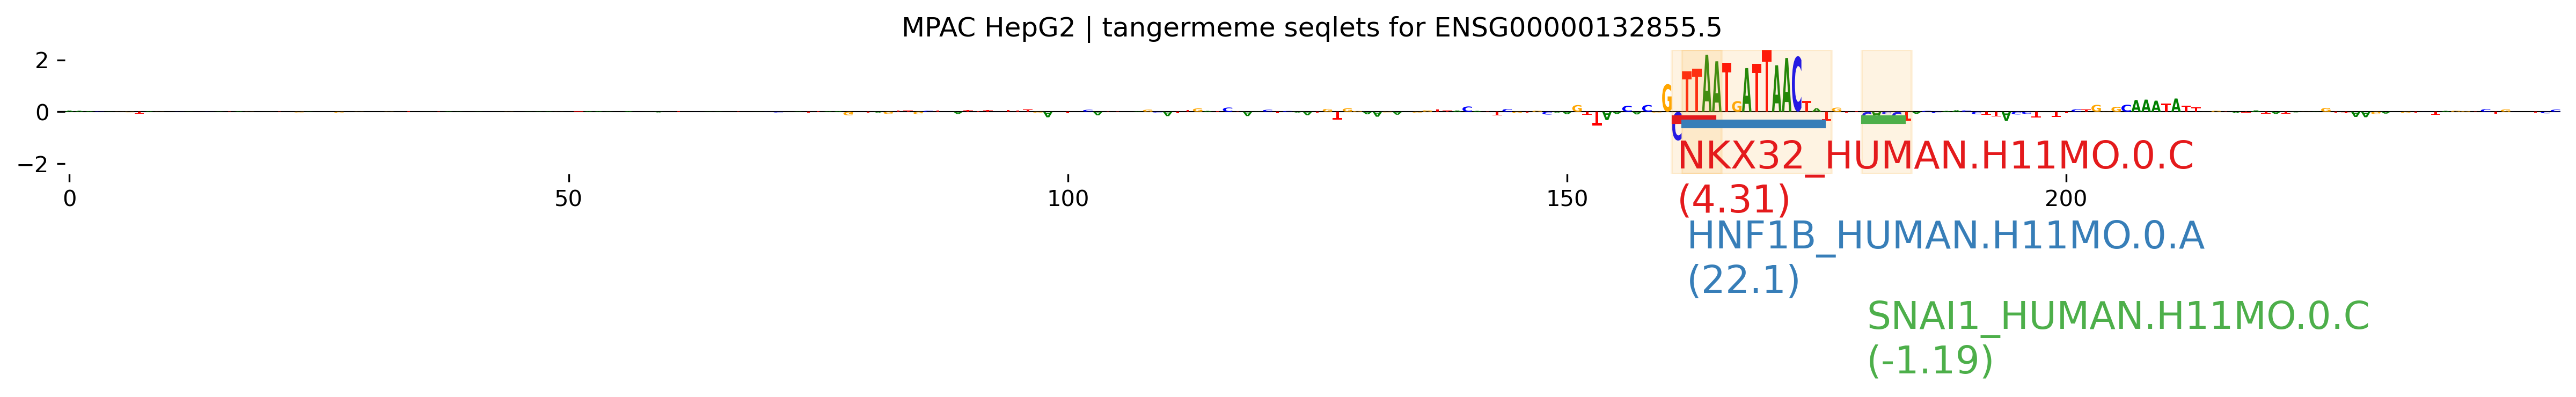

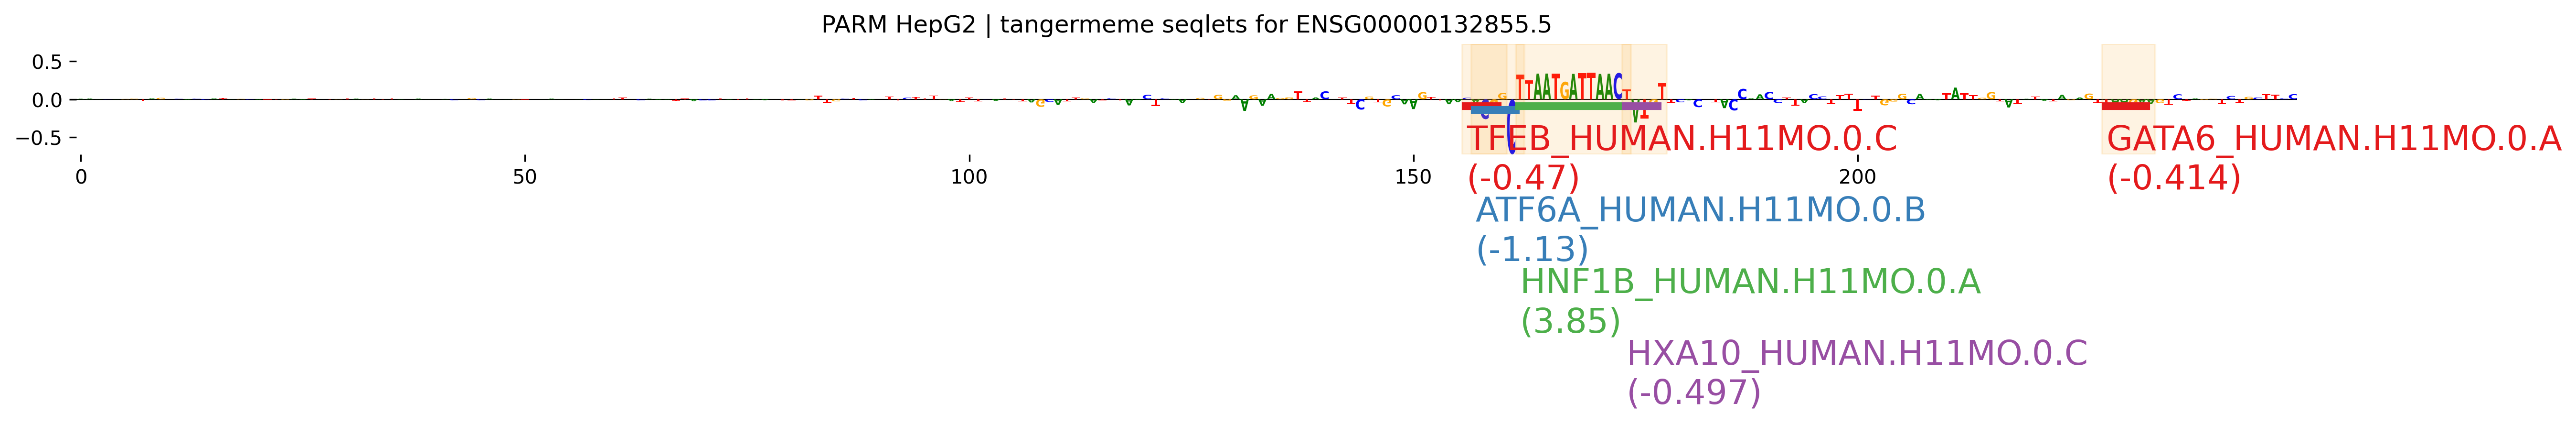

no seqlets for this enhancer at this threshold


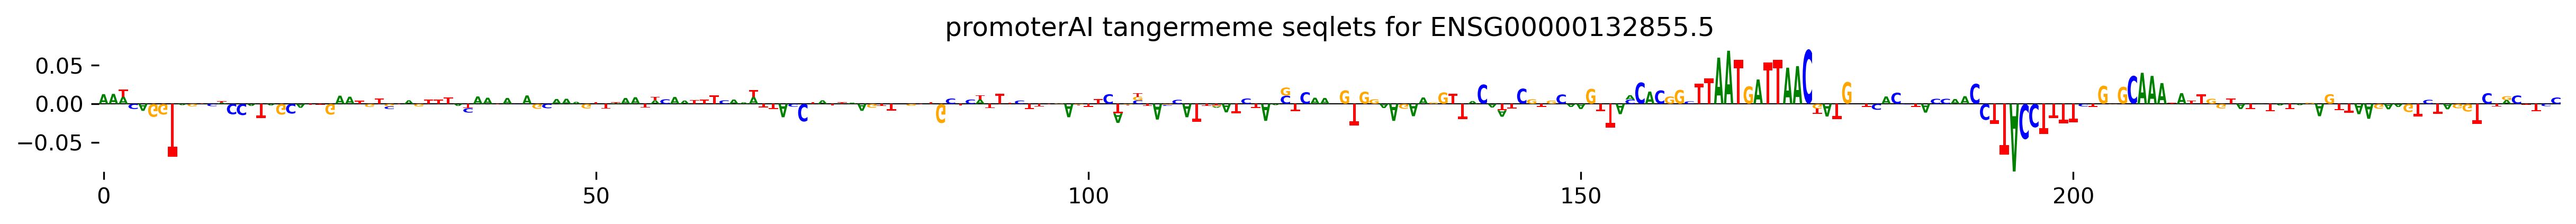

In [35]:
# ENSG00000132855.5
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000132855.5',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000132855.5',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000132855.5',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000132855.5',
    promoterAI_plotLogo_dict
)

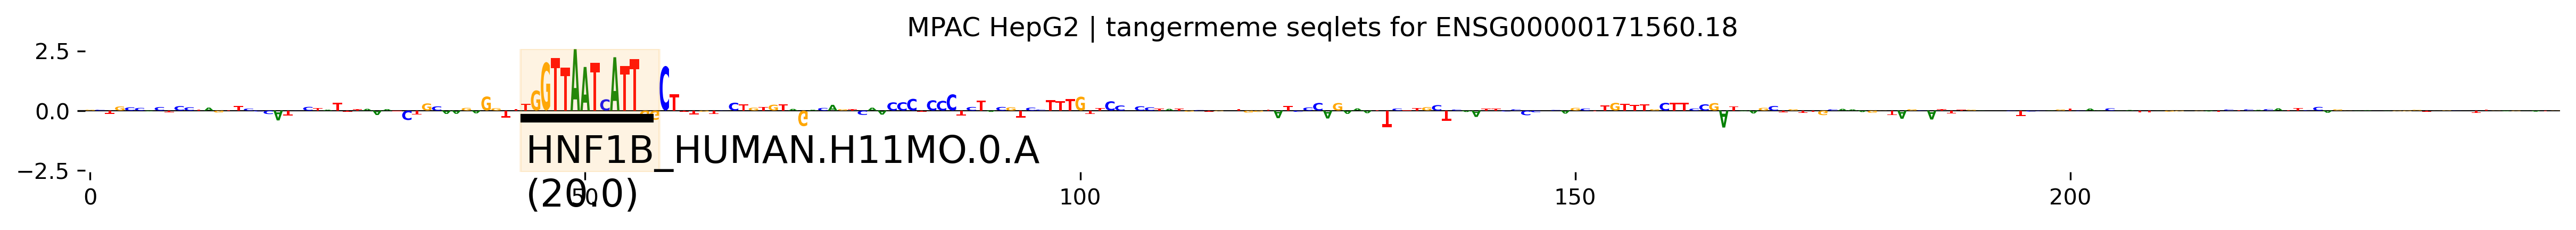

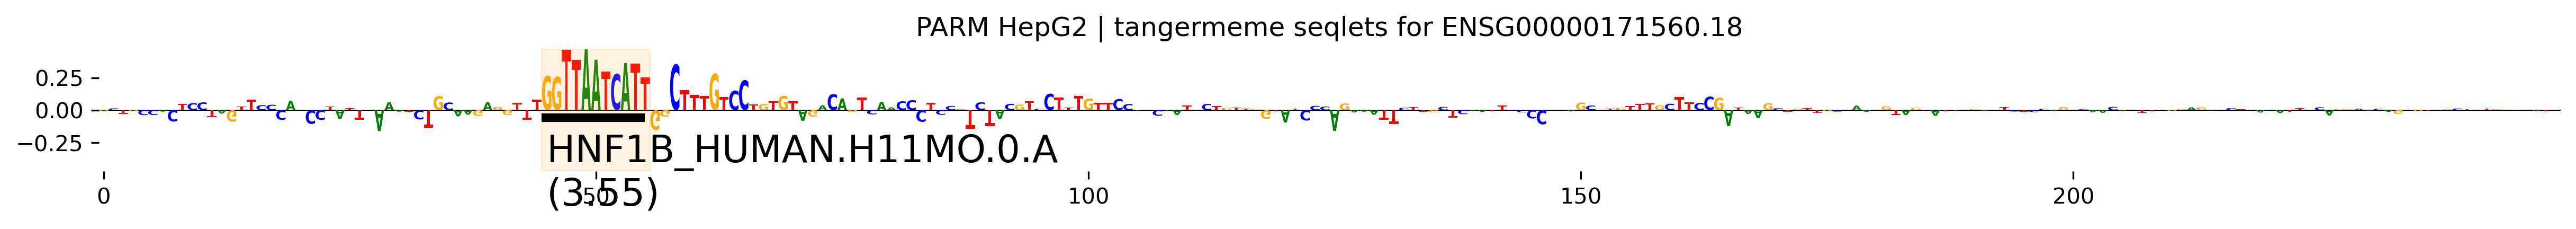

no seqlets for this enhancer at this threshold


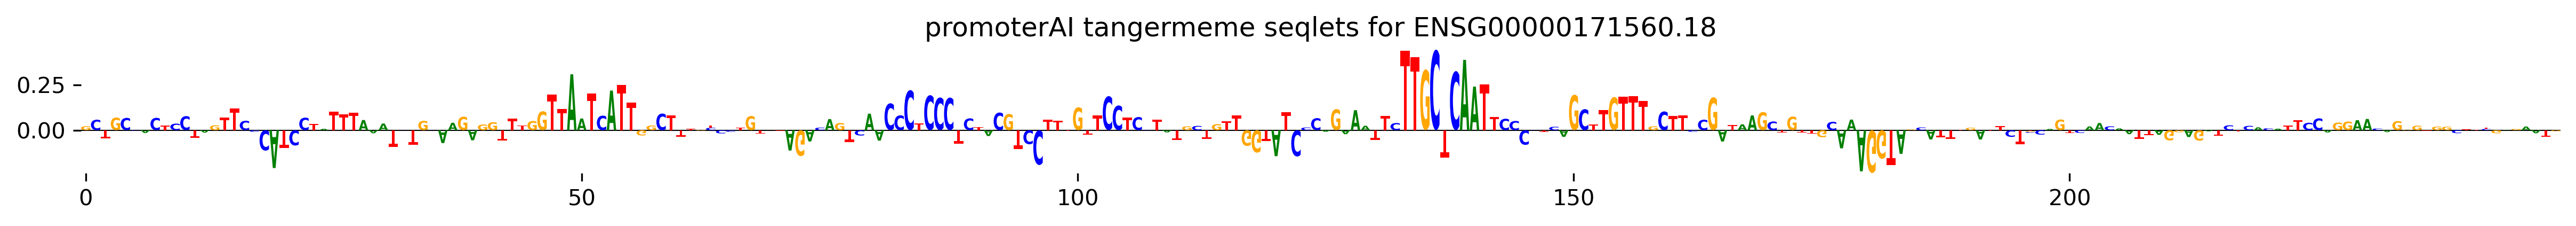

In [36]:
# ENSG00000171560.18
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000171560.18',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000171560.18',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000171560.18',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000171560.18',
    promoterAI_plotLogo_dict
)

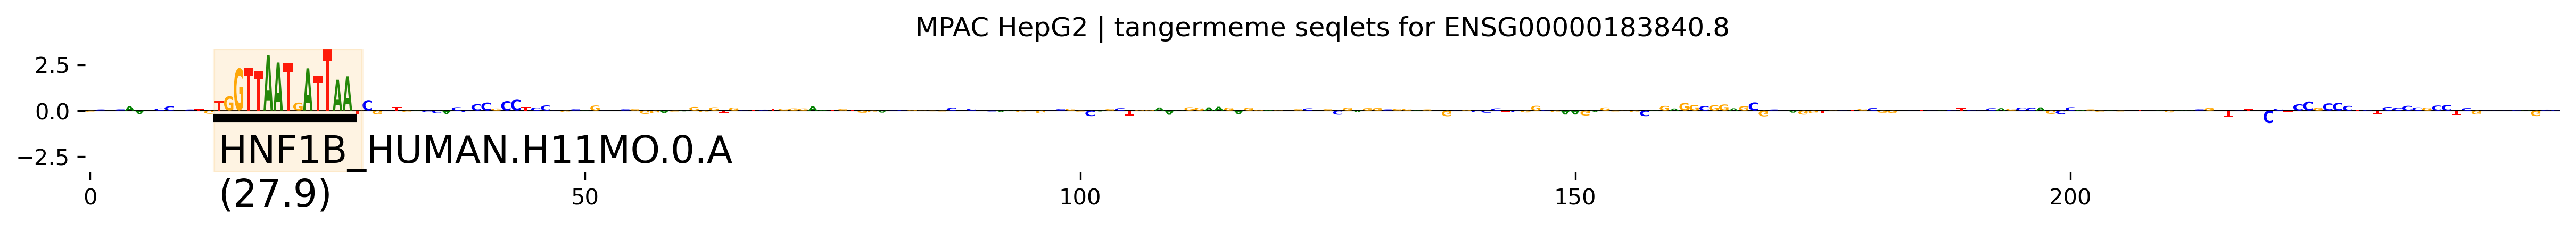

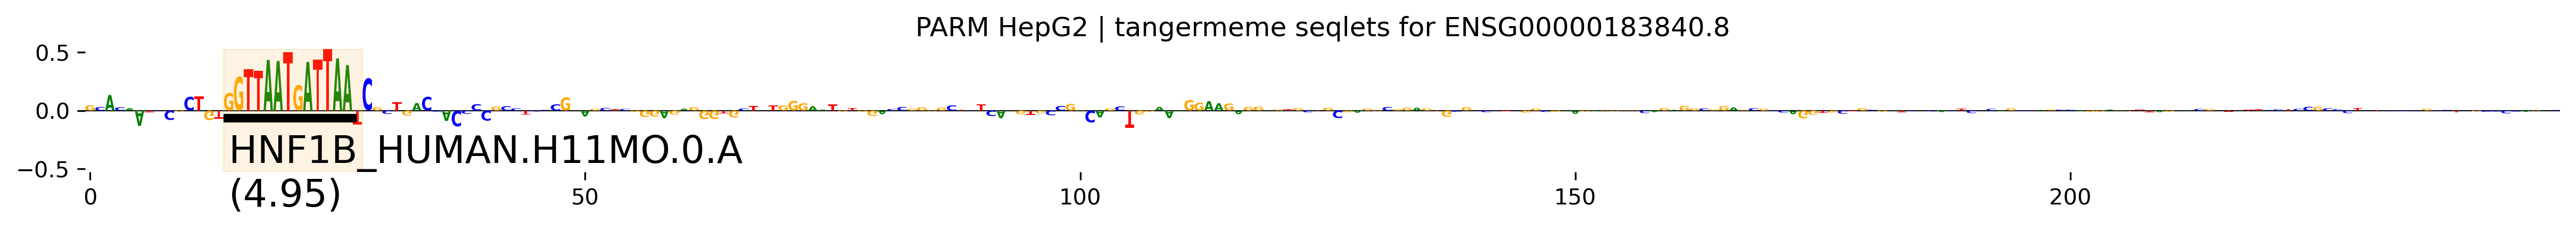

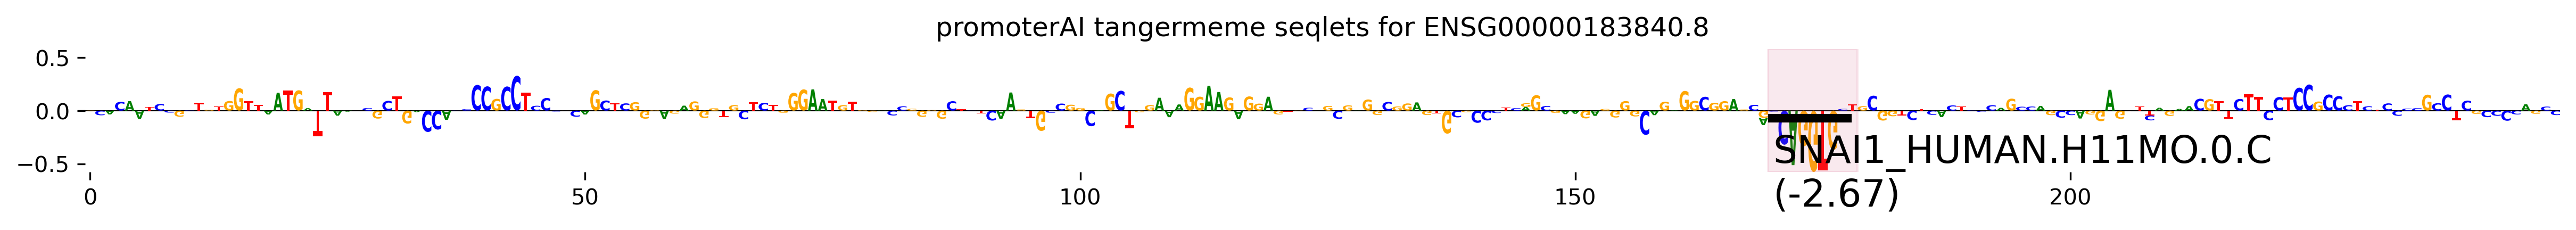

In [41]:
# ENSG00000183840.8
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000183840.8',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000183840.8',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000183840.8',
#     mpac_k_plotLogo_dict,
#     'K562',
#     'MPAC'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000183840.8',
    promoterAI_plotLogo_dict
)

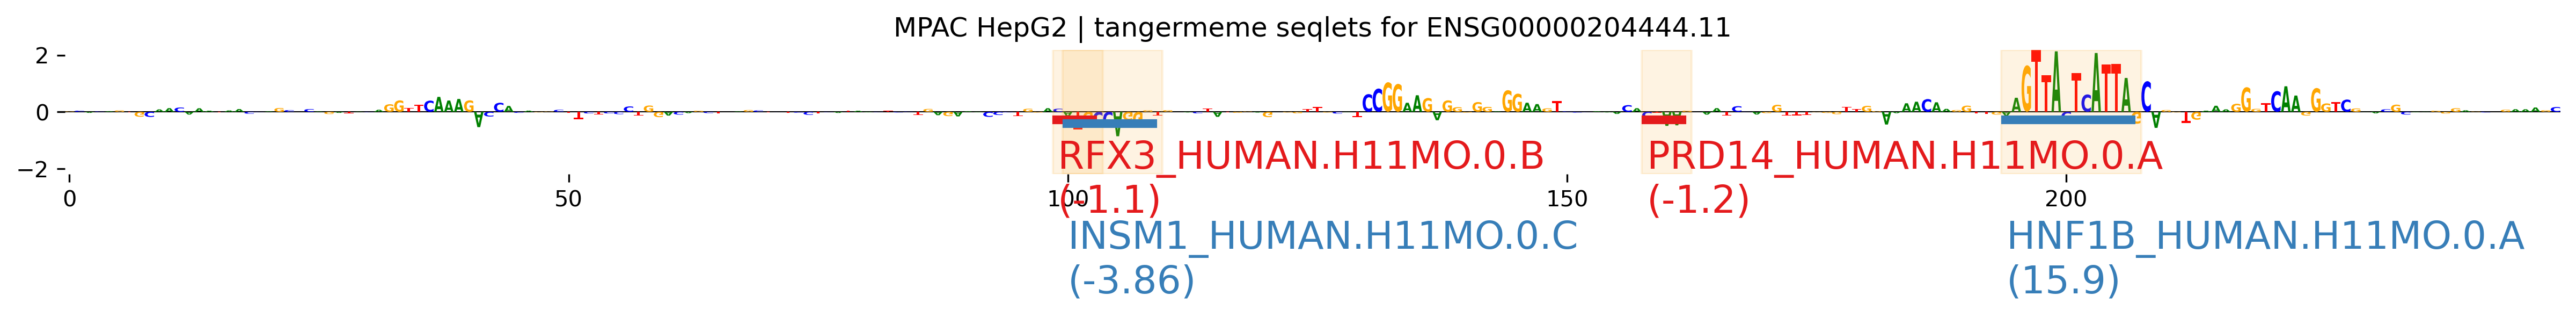

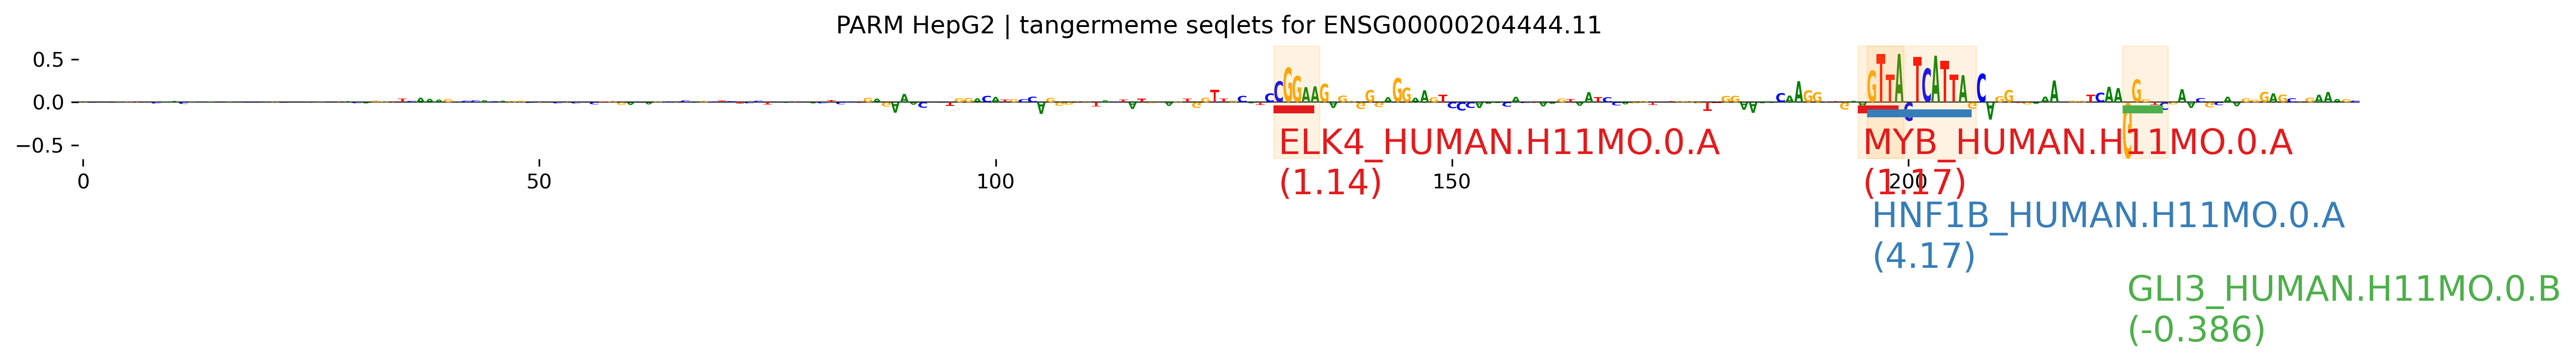

no seqlets for this enhancer at this threshold


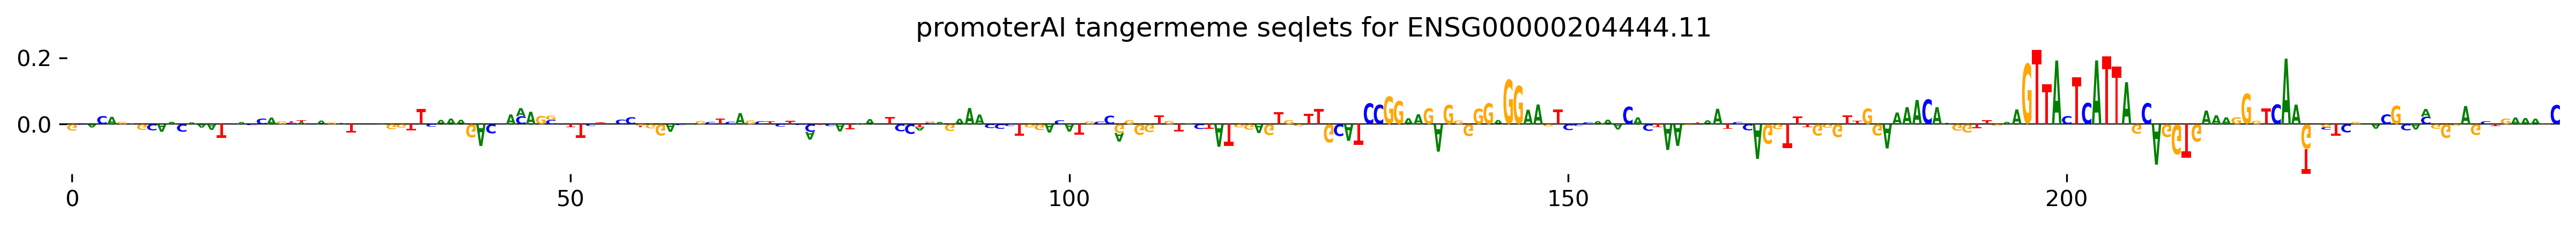

In [38]:
# ENSG00000204444.11
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000204444.11',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000204444.11',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000204444.11',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000204444.11',
    promoterAI_plotLogo_dict
)

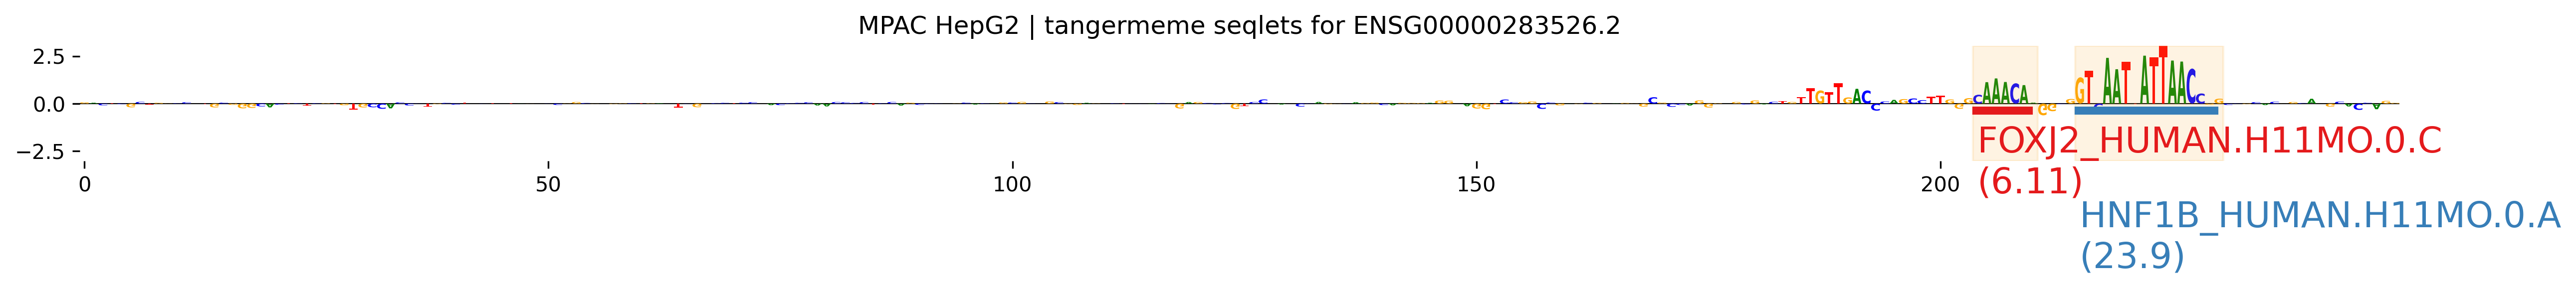

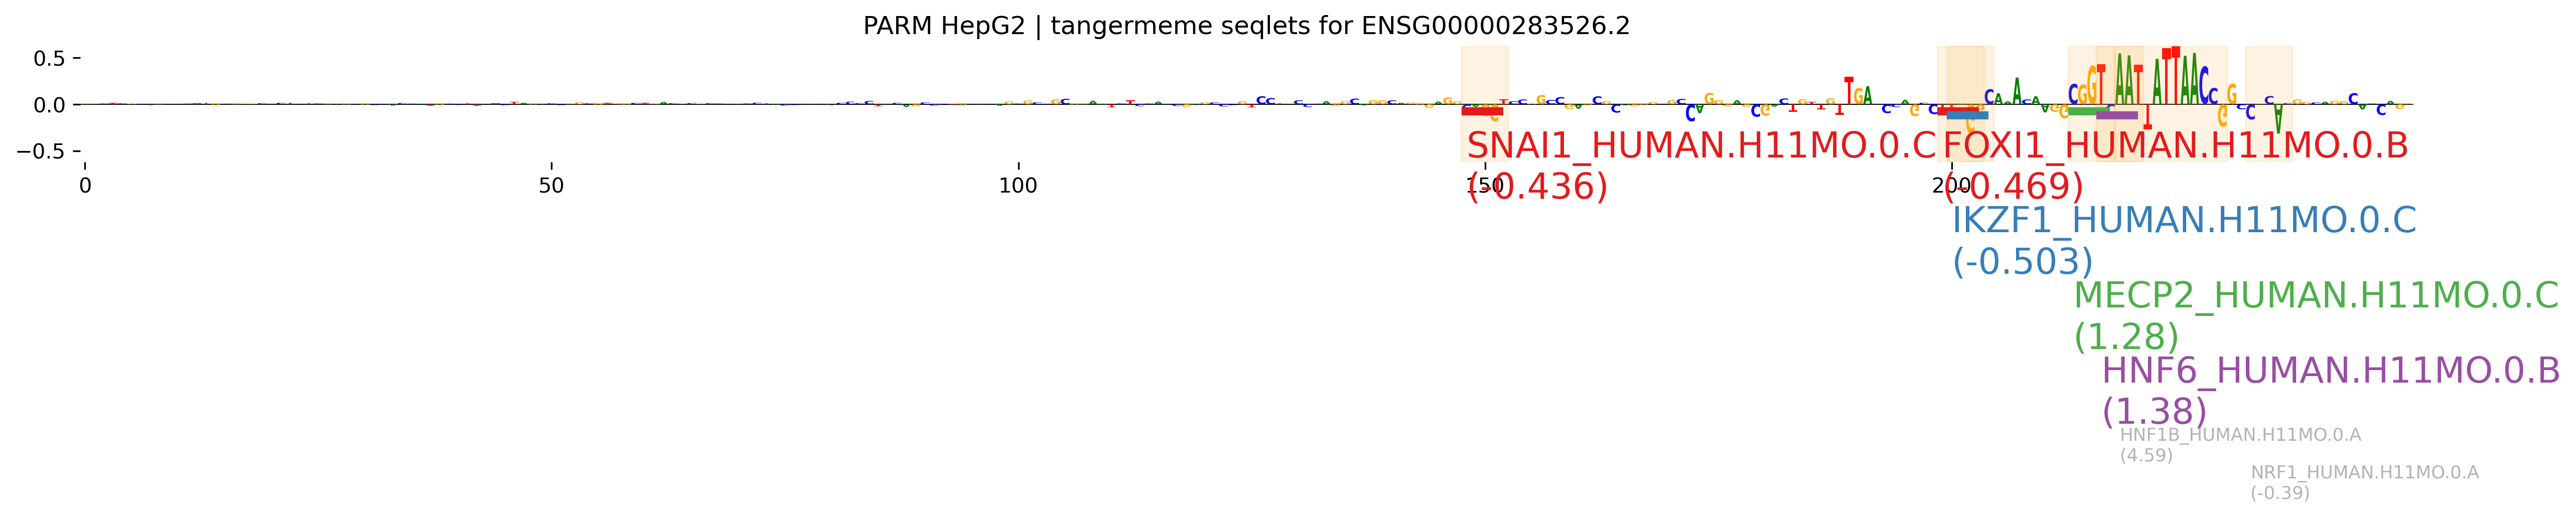

no seqlets for this enhancer at this threshold


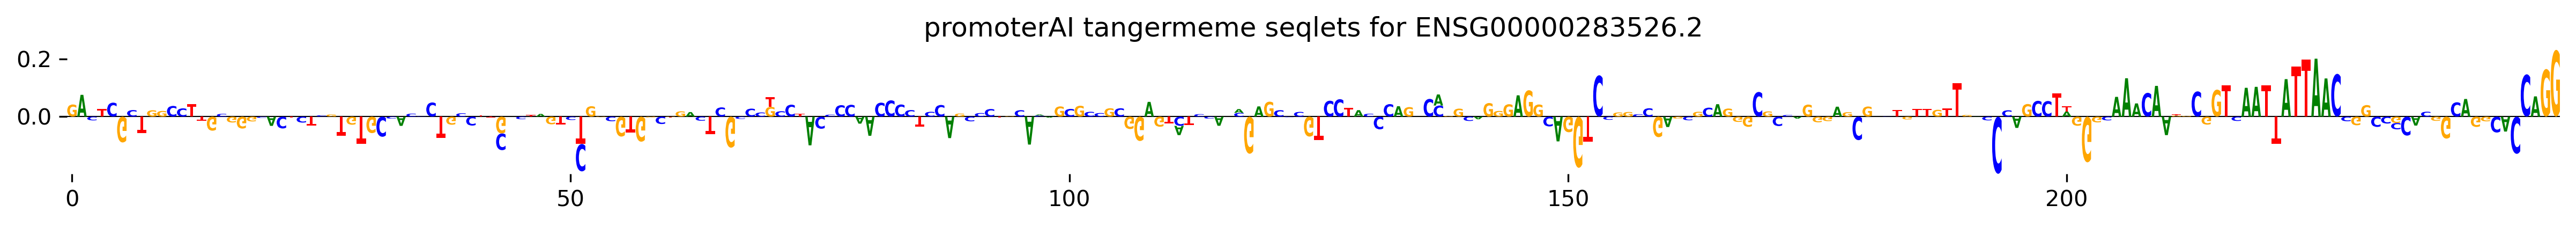

In [42]:
# ENSG00000283526.2
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000283526.2',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000283526.2',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000283526.2',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000283526.2',
    promoterAI_plotLogo_dict
)

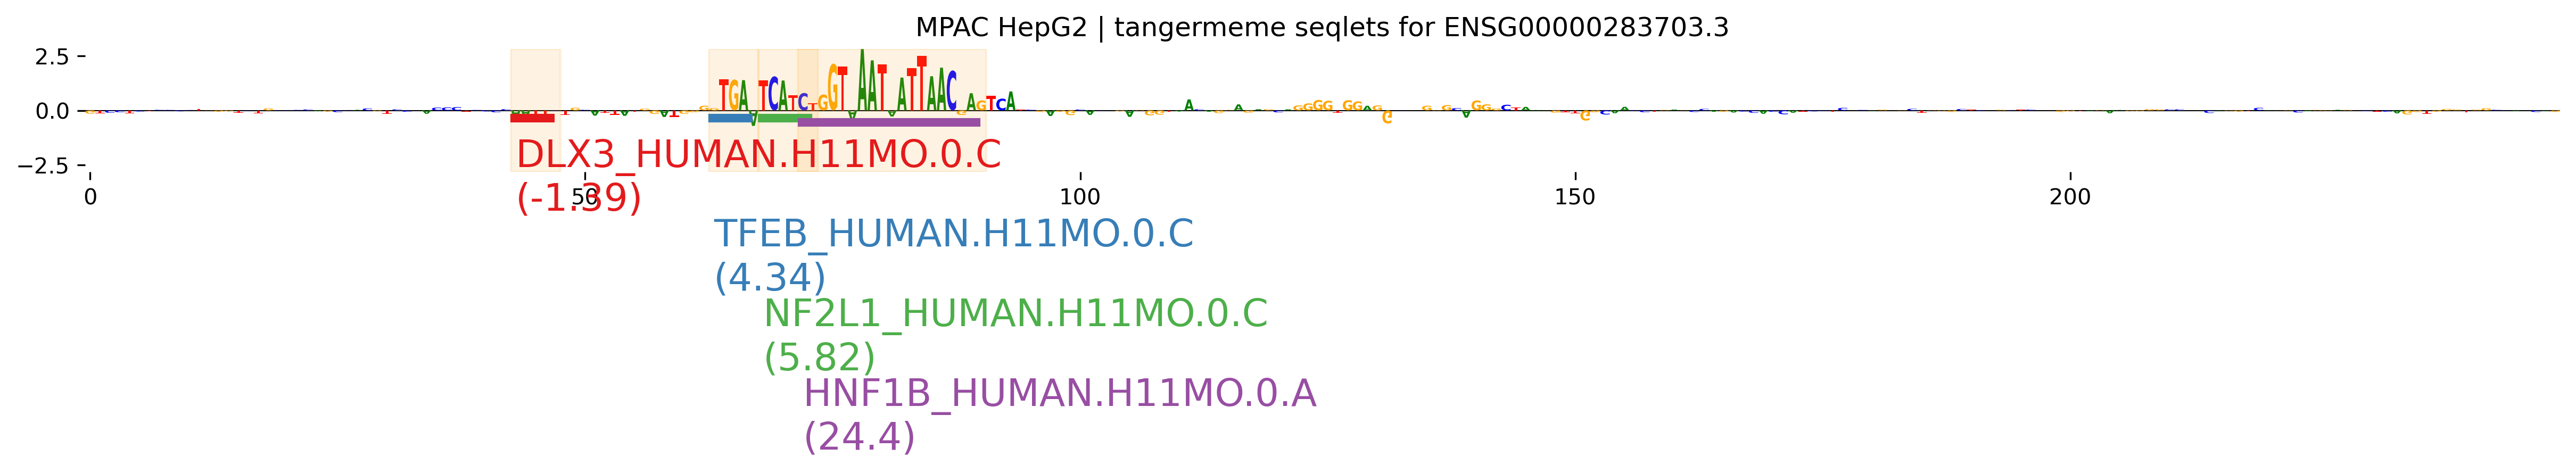

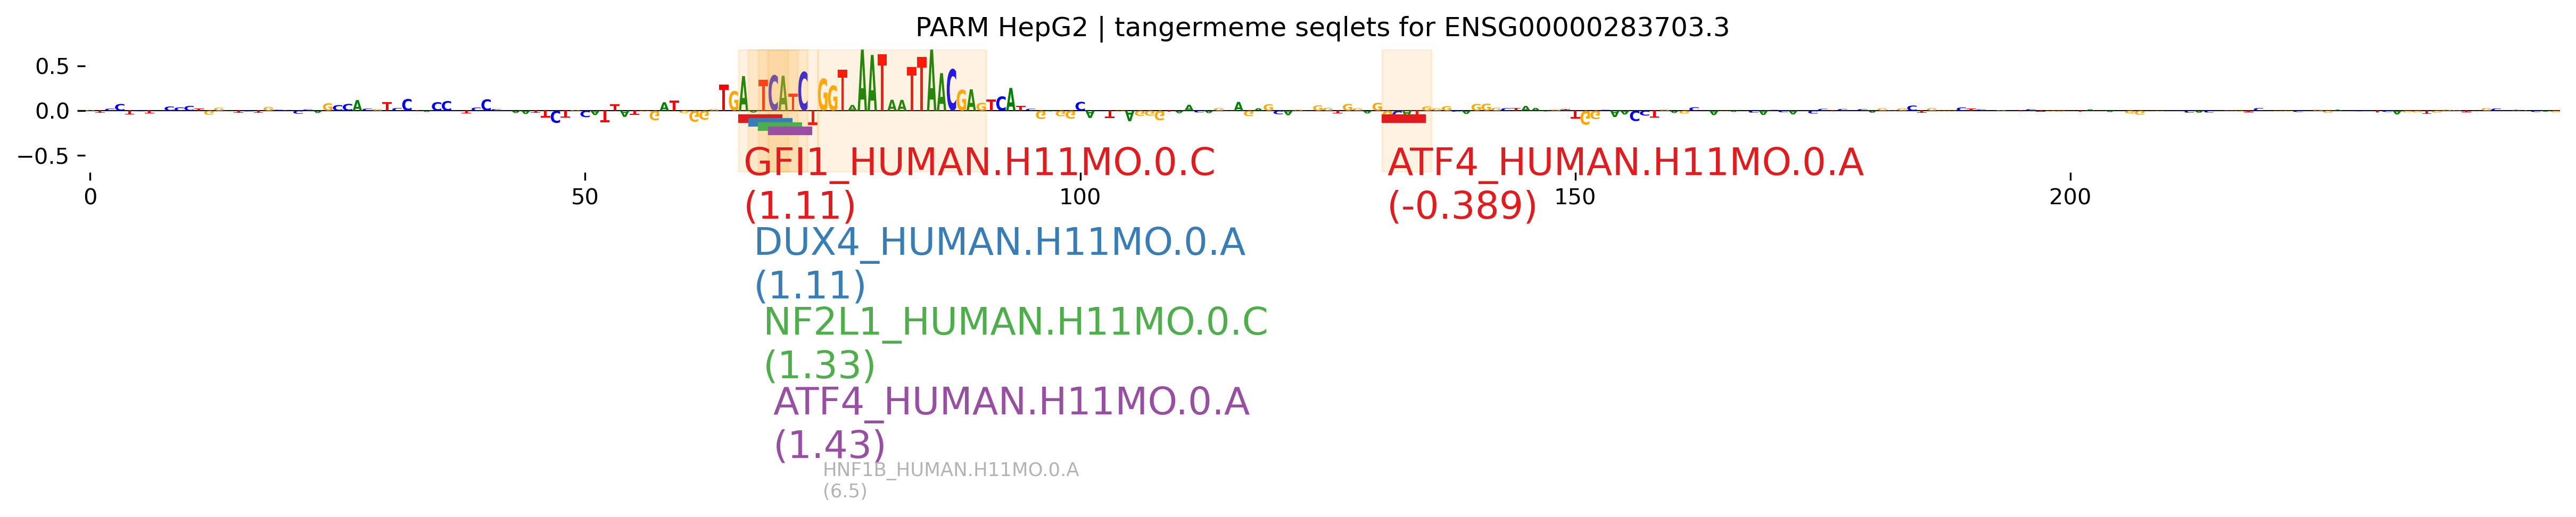

no seqlets for this enhancer at this threshold


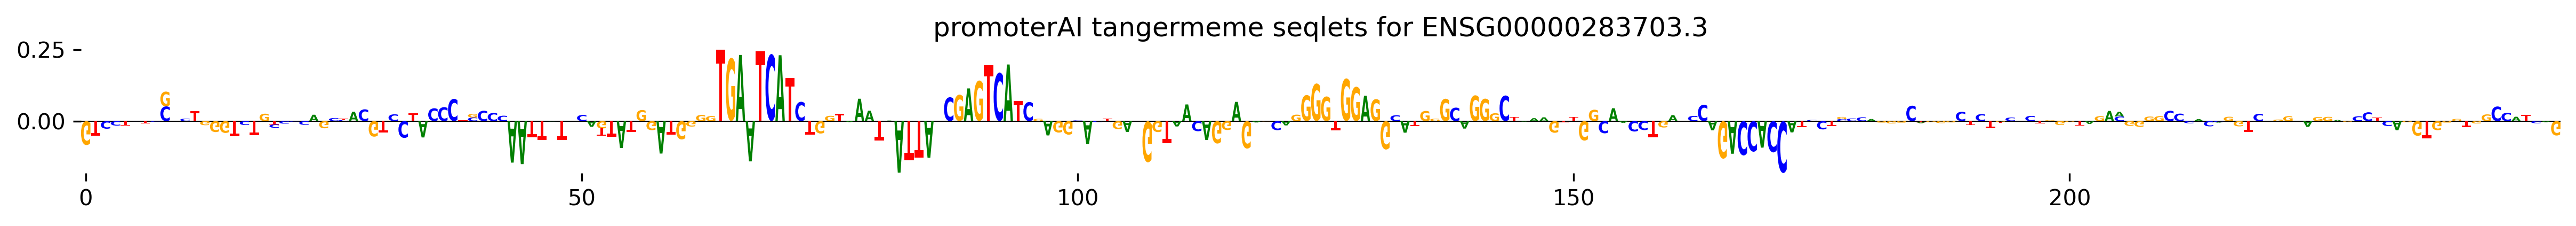

In [43]:
# ENSG00000283703.3
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000283703.3',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000283703.3',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000283703.3',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000283703.3',
    promoterAI_plotLogo_dict
)

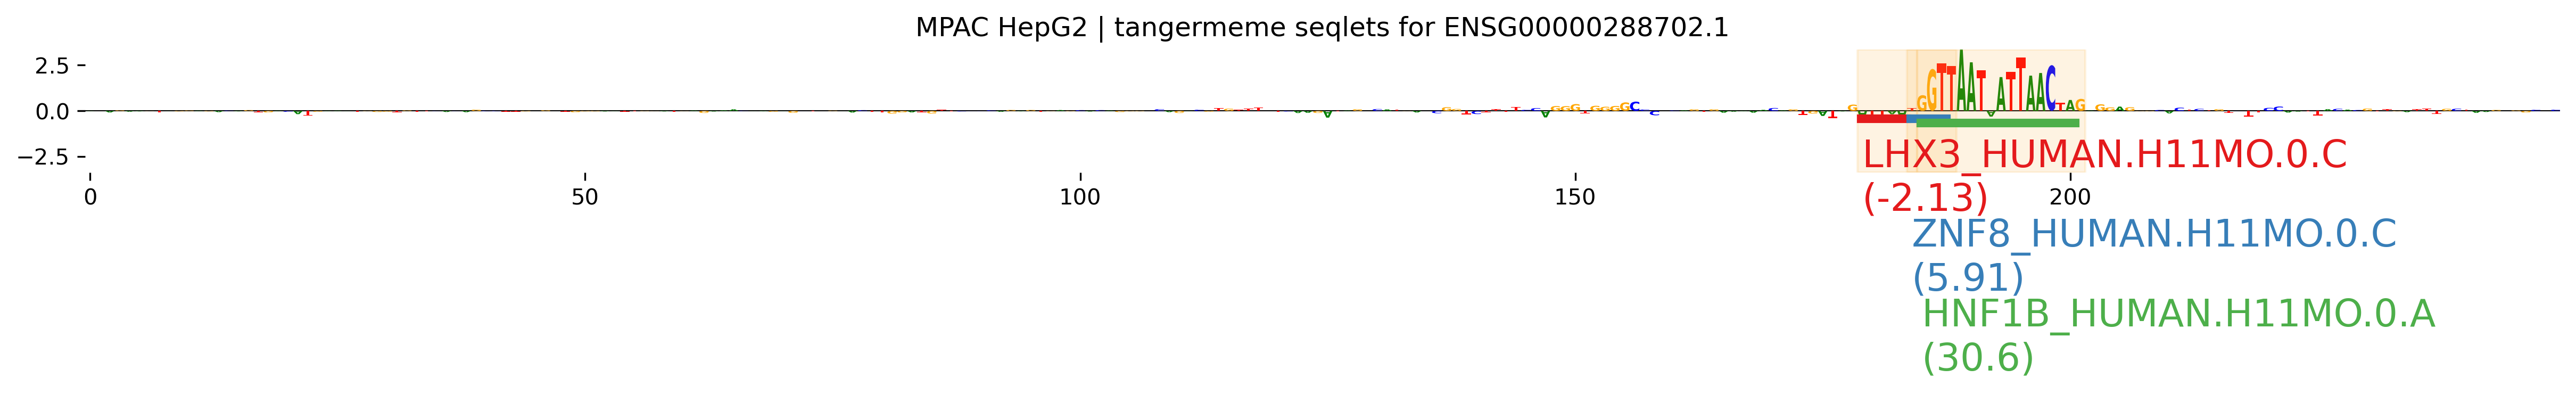

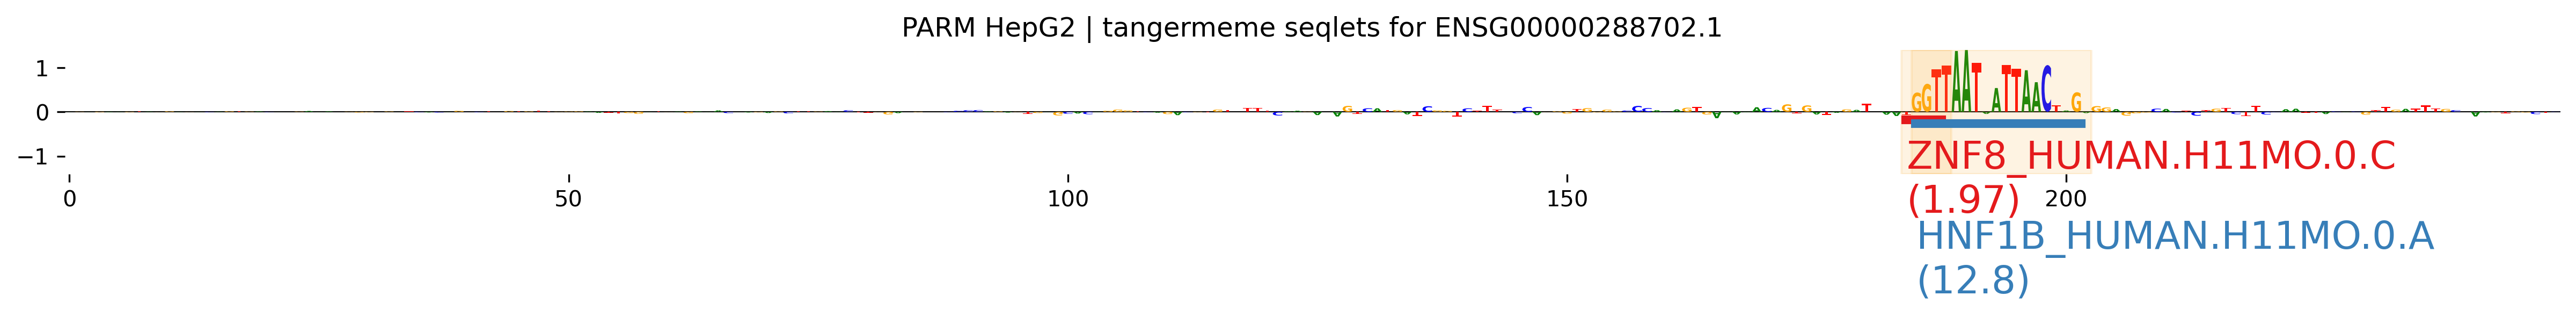

no seqlets for this enhancer at this threshold


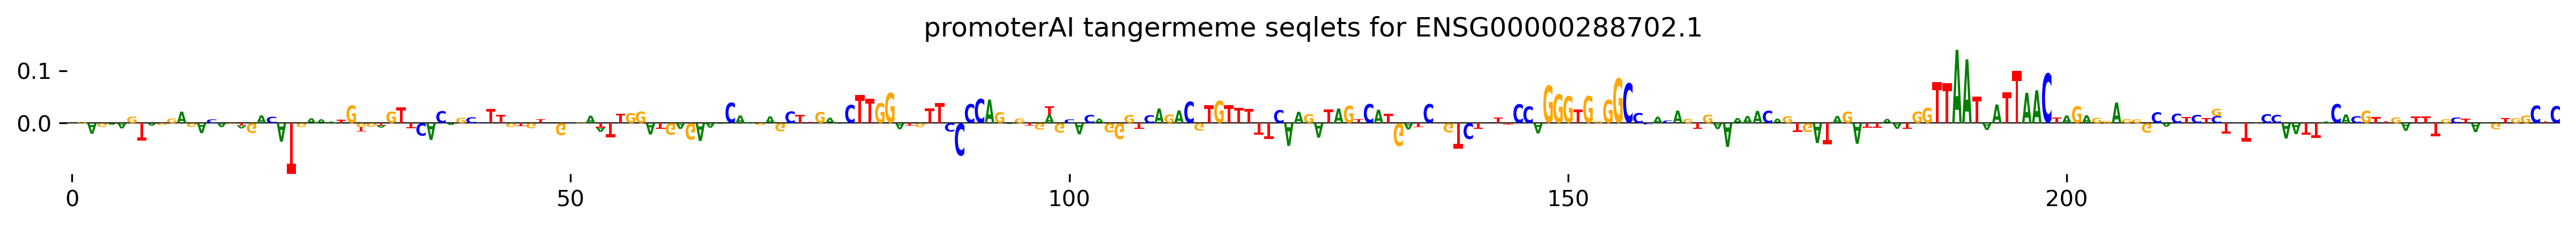

In [44]:
# ENSG00000288702.1
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000288702.1',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000288702.1',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000288702.1',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000288702.1',
    promoterAI_plotLogo_dict
)

In [45]:
### MPAC ONLY ###

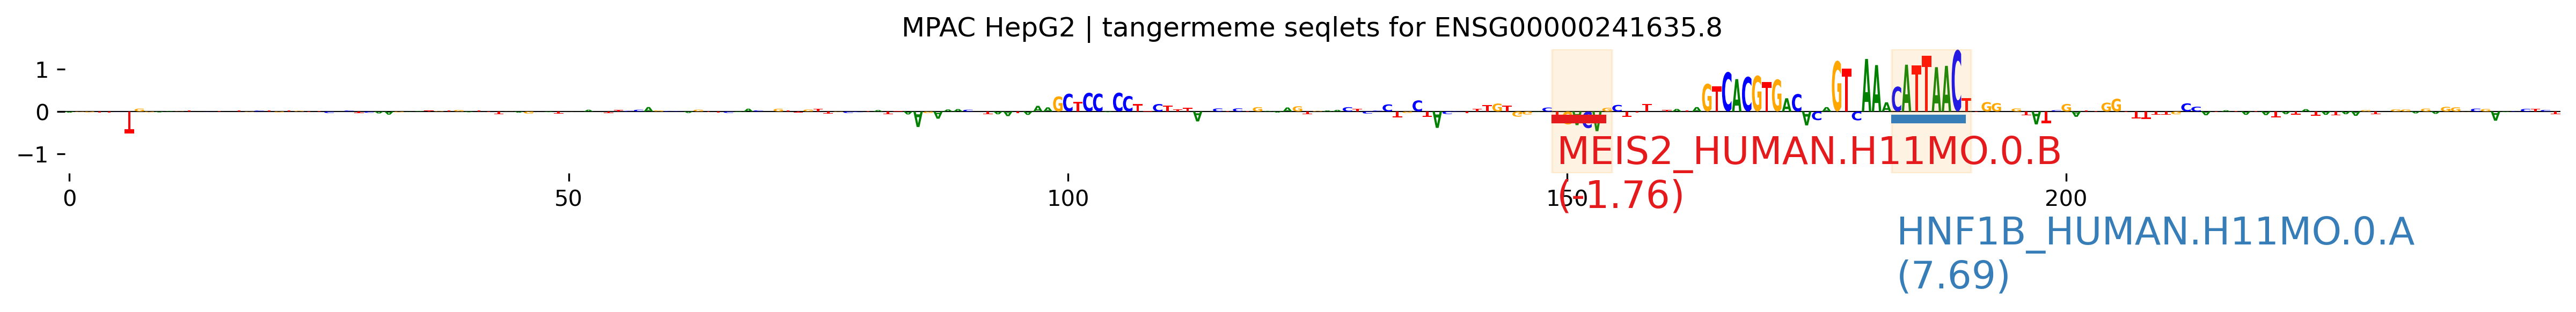

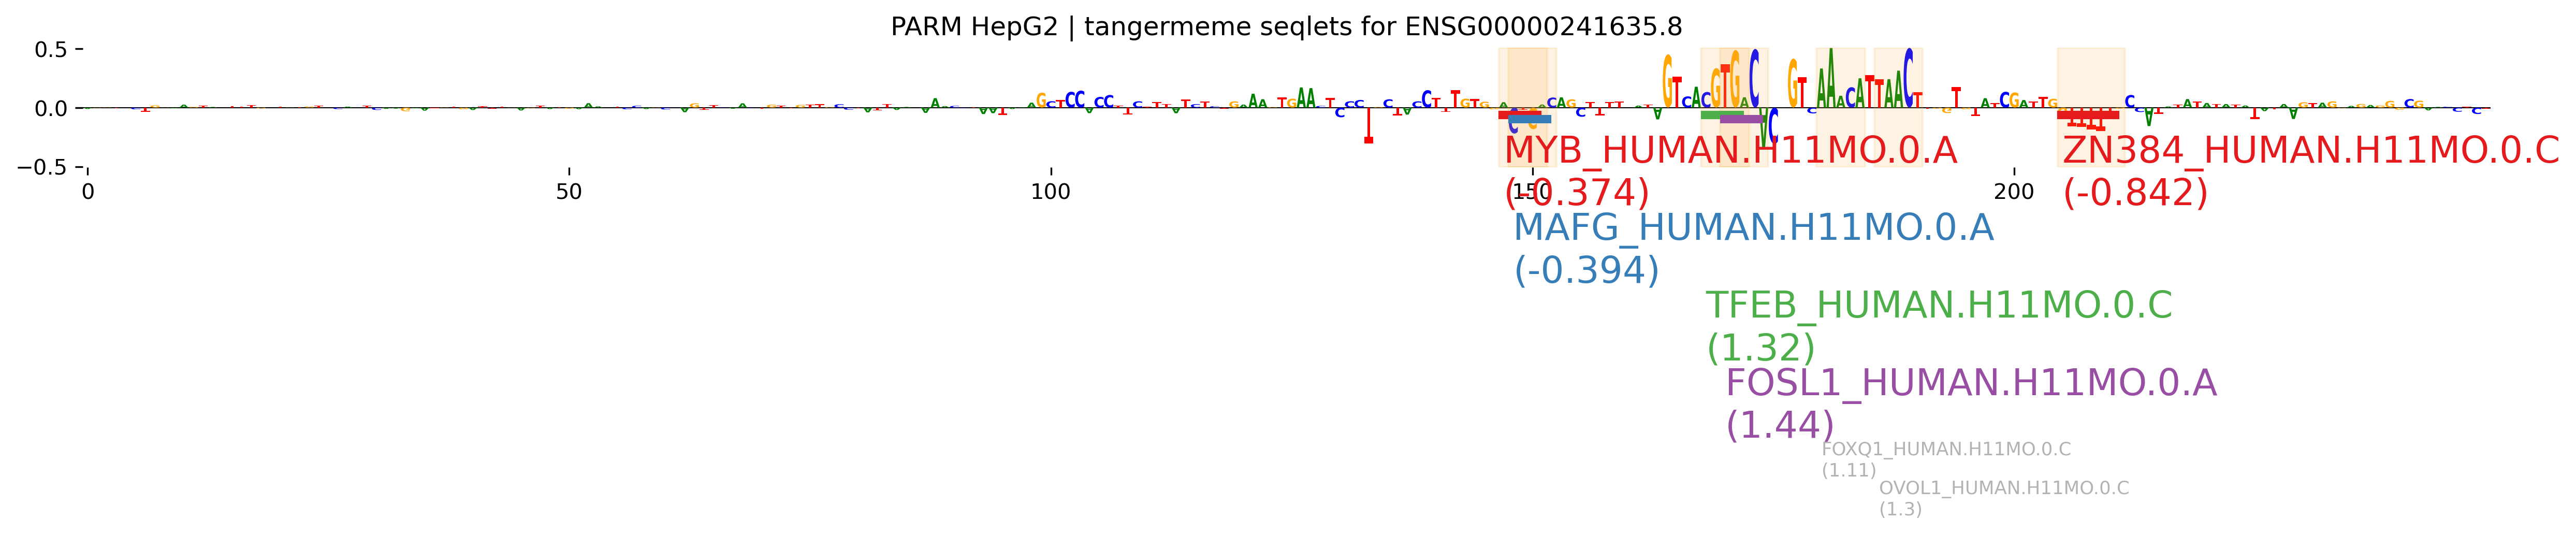

no seqlets for this enhancer at this threshold


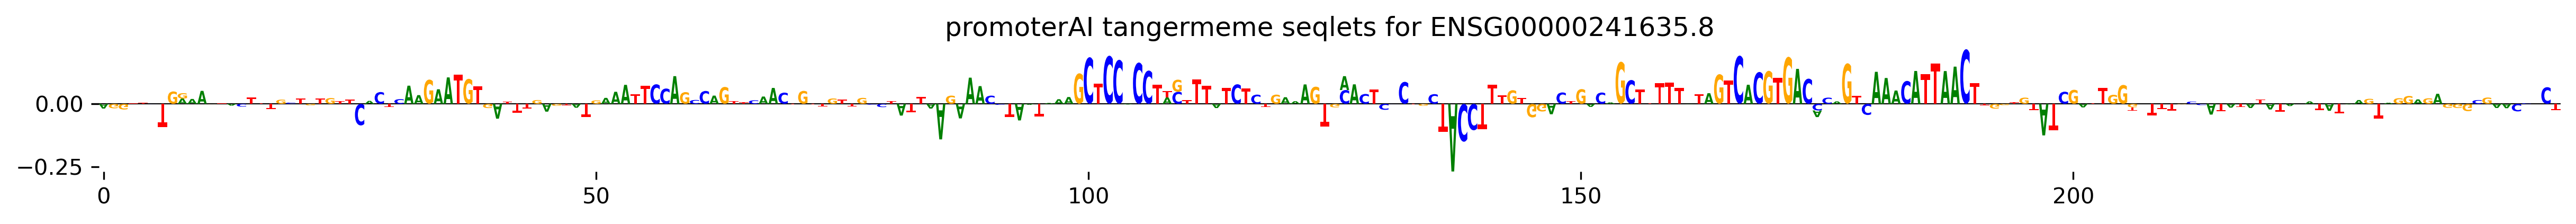

In [46]:
# ENSG00000241635.8
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000241635.8',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000241635.8',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000288702.1',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000241635.8',
    promoterAI_plotLogo_dict
)

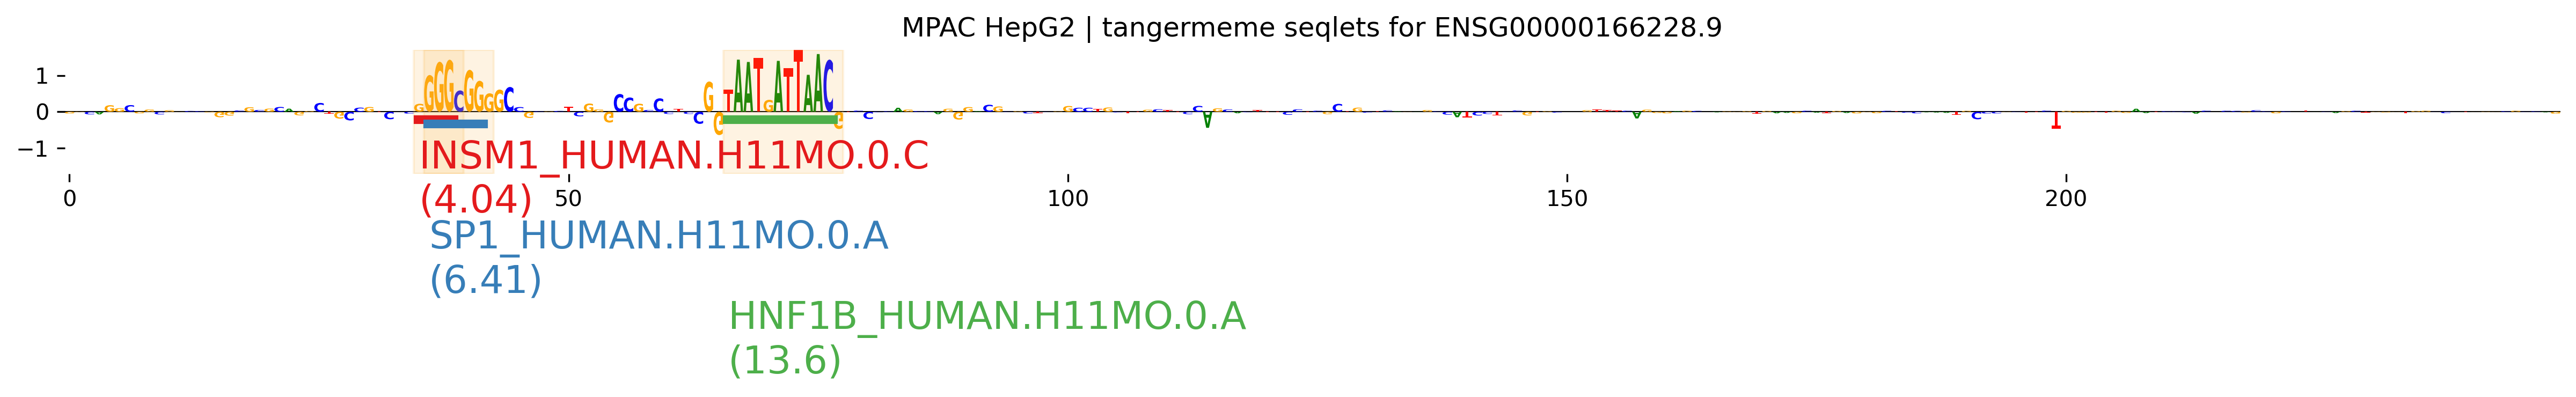

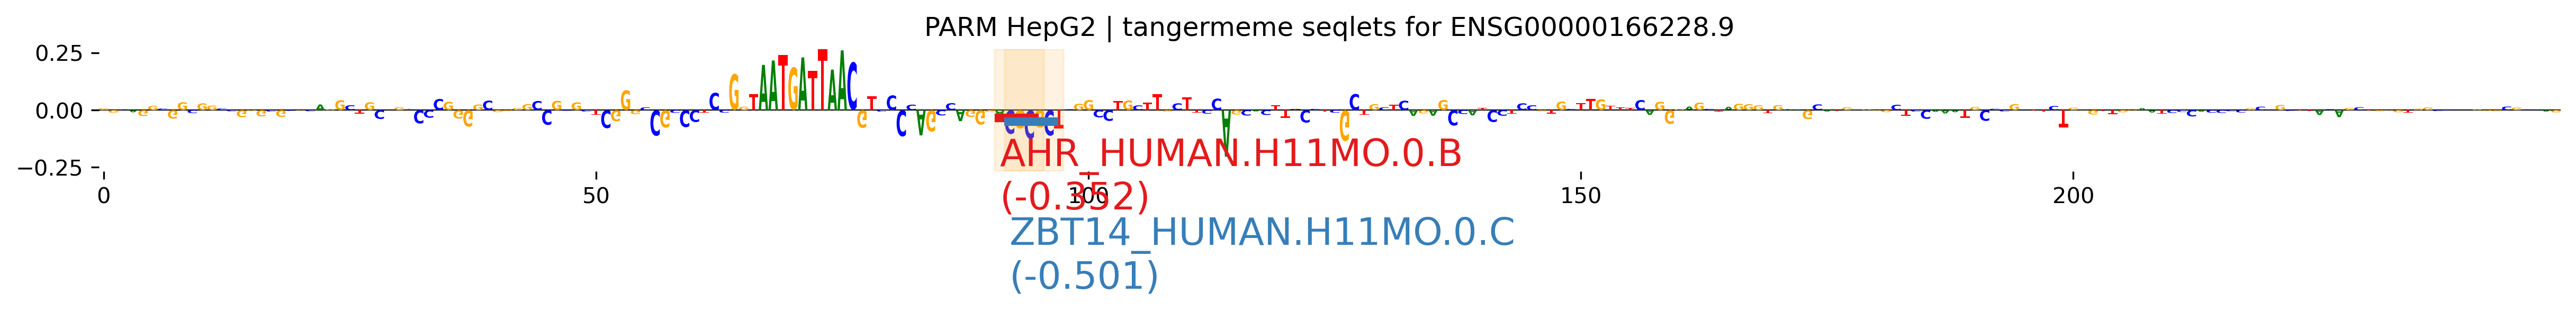

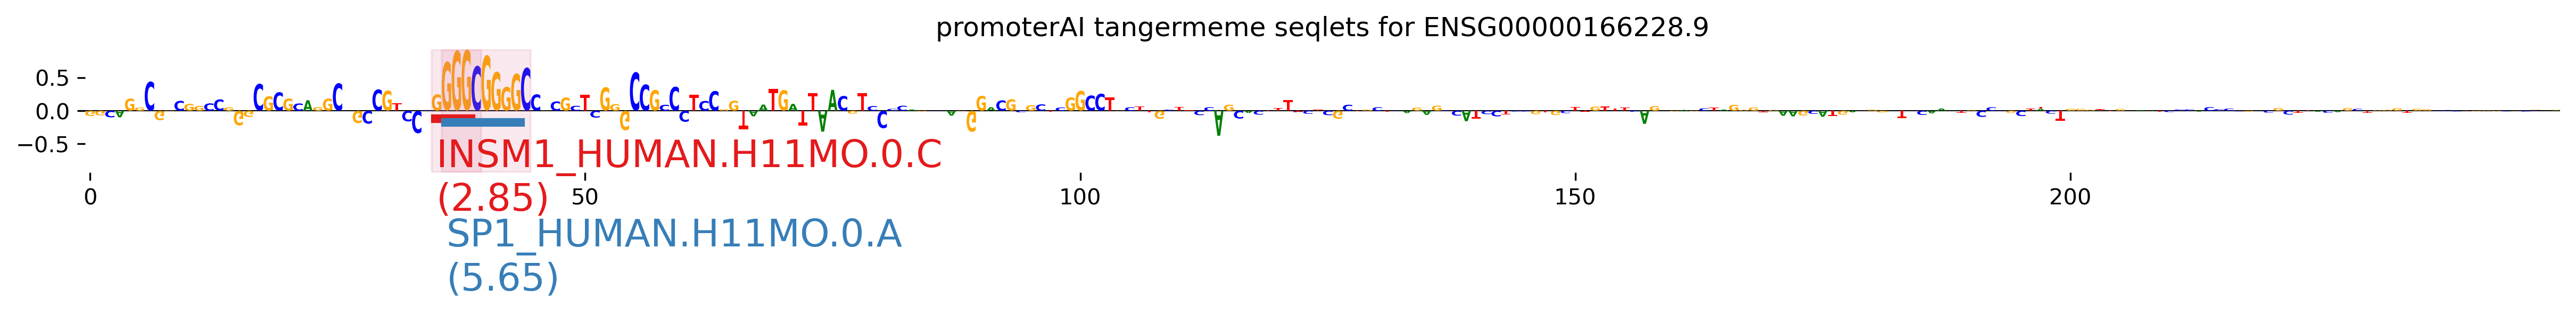

In [7]:
# ENSG00000166228.9
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000166228.9',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000166228.9',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000166228.9',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000166228.9',
    promoterAI_plotLogo_dict
)

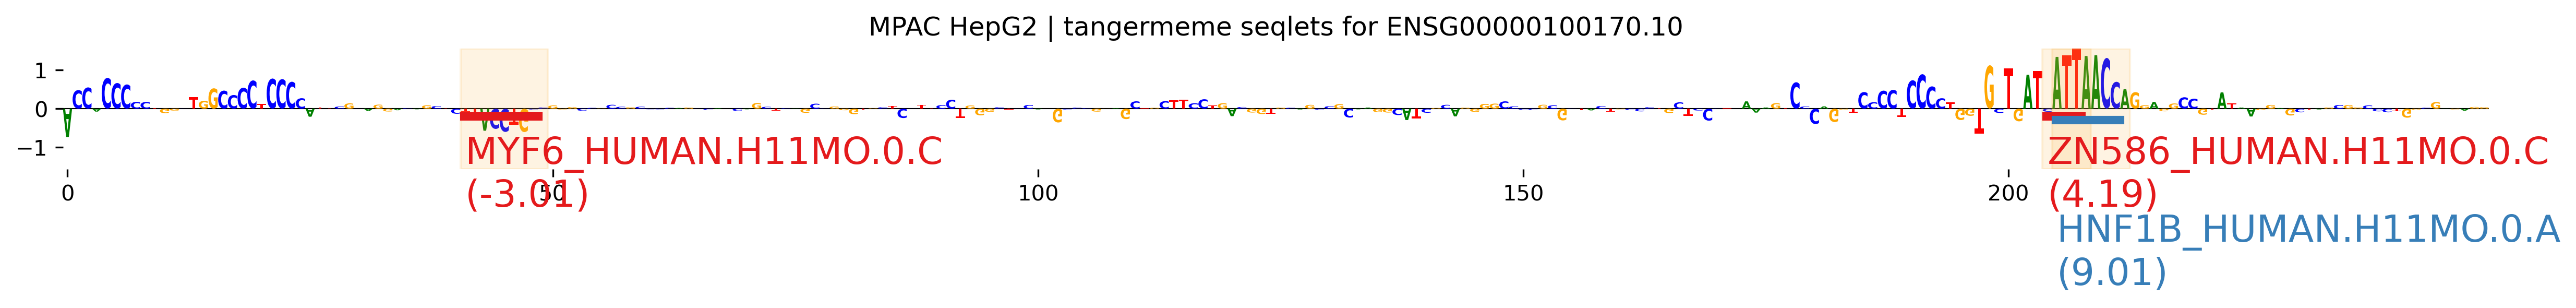

no seqlets for this enhancer at this threshold


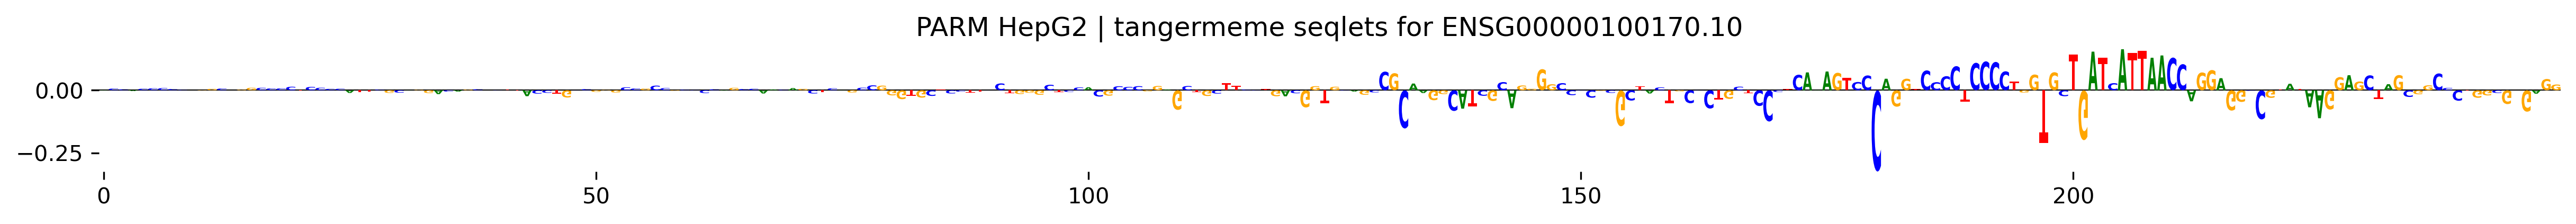

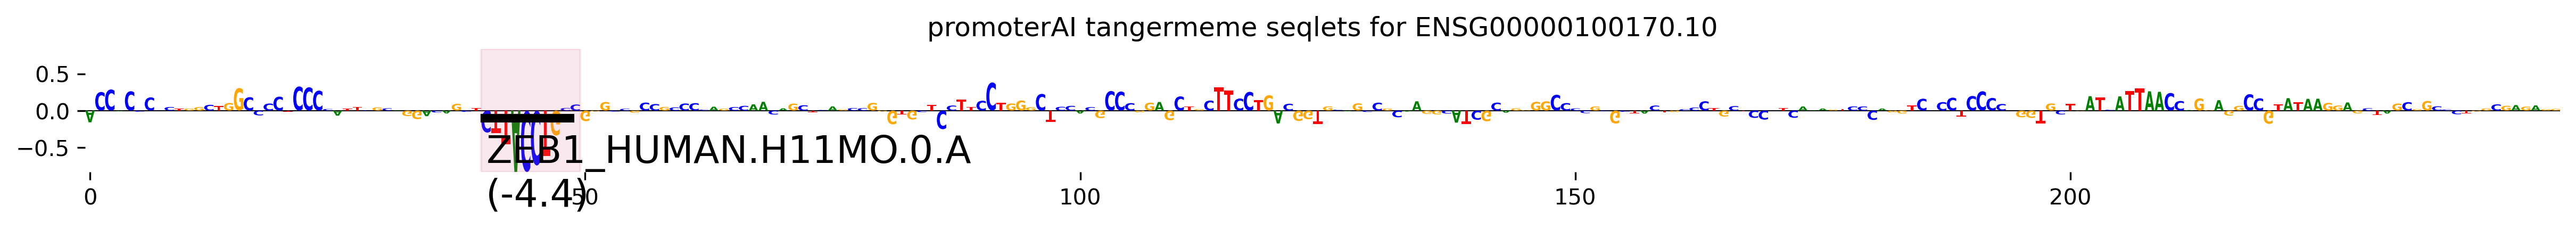

In [8]:
# ENSG00000100170.10
# mpac hepg2
plot_specific_logos_mpac(
    mpac_h_seqlet_calls,
    mpac_h_full_ann_seqlets,
    'ENSG00000100170.10',
    mpac_h_plotLogo_dict,
    'HepG2',
    'MPAC'
)
# parm hepg2
plot_specific_logos_mpac(
    parm_h_seqlet_calls,
    parm_h_full_ann_seqlets,
    'ENSG00000100170.10',
    parm_h_plotLogo_dict,
    'HepG2',
    'PARM'
)
# # mpac k562
# plot_specific_logos_mpac(
#     mpac_k_seqlet_calls,
#     mpac_k_full_ann_seqlets,
#     'ENSG00000166228.9',
#     mpac_k_plotLogo_dict,
#     'K562'
# )
# promoterAI
plot_specific_logos_pAI(
    promoterAI_seqlet_calls,
    promoterAI_full_ann_seqlets,
    'ENSG00000100170.10',
    promoterAI_plotLogo_dict
)